## Multilayer perceptron

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
np.random.seed(5139)

In [2]:
filtered_df = pd.read_csv(r'C:\GitHub_AI_Workshop\codes\5_yield_prediction\2_ml_models\yield_pani_seed_count.csv')
filtered_df = filtered_df.dropna()
filtered_df

,Plot_Pedigree,Plot,Pedigree,Range,Row,Pass,Rep,Yld_ton_ha,GT_Pan_Count,DG_Pan_Count,...,Lab_Pan_Size_cm2,MK_Pan_Size_cm2,Predict_Pan_Size_Pixel,Mach_Seed_Count,Pan_Seed_Count,Reg_Seed_Count,Spr_Seed_Count,Microscope_Area_mm2,DG_Seed_Area_mm2,SKCS_Seed_dia_mm
0,2005-SC964,2005,SC964,2,6,2,1,3.941257,166,129,...,119.284937,71.477387,15499.42034,1839,1276,2041,2006.0,9.947,11.692672,2.410843
1,2009-RTx430BL,2009,RTx430BL,2,10,3,1,4.333421,139,96,...,131.744064,66.349287,14985.00490,882,742,1309,1019.0,12.038,7.009835,3.050454
2,2013-Tx7000,2013,Tx7000,2,14,4,1,5.192731,168,151,...,217.827004,91.675497,15368.33830,2275,1573,1898,2402.0,11.847,16.766636,3.066632
3,2017-RLBK1,2017,RLBK1,2,18,5,1,1.378816,102,103,...,128.253696,45.303214,11945.51458,696,485,1273,727.0,10.234,8.325976,2.603187
4,2021-SC326-6,2021,SC326-6,2,22,6,1,3.612592,139,116,...,301.718209,140.481508,11716.55753,2868,1283,1869,2844.0,10.059,14.686166,2.493731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,7057-SC348,7057,SC348,7,58,15,3,4.691004,162,143,...,290.669999,132.968718,14443.86043,1228,893,1185,1387.0,13.822,18.901944,3.470536
104,7061-2219-3,7061,2219-3,7,62,16,3,2.665269,142,129,...,138.694163,79.016643,21268.46541,1406,1143,1863,1341.0,11.228,10.861323,2.820719
105,7065-SN72_PINK_KAFIR,7065,SN72_PINK_KAFIR,7,66,17,3,4.819019,162,143,...,418.212315,132.810339,21307.71462,1562,1152,1380,1611.0,9.038,9.194070,2.654018
106,7069-2290-19,7069,2290-19,7,70,18,3,5.339355,160,142,...,227.874814,141.366547,14740.30994,1483,1492,1532,1572.0,11.696,12.537695,3.012687


In [3]:
filtered_df.columns

Index(['Plot_Pedigree', 'Plot', 'Pedigree', 'Range', 'Row', 'Pass', 'Rep',
       'Yld_ton_ha', 'GT_Pan_Count', 'DG_Pan_Count', 'GT_Pan_Size_cm2',
       'B_Box_Pan_Size_cm2', 'Lab_Pan_Size_cm2', 'MK_Pan_Size_cm2',
       'Predict_Pan_Size_Pixel', 'Mach_Seed_Count', 'Pan_Seed_Count',
       'Reg_Seed_Count', 'Spr_Seed_Count', 'Microscope_Area_mm2',
       'DG_Seed_Area_mm2', 'SKCS_Seed_dia_mm'],
      dtype='str')

In [4]:
# Define X, y, print X
X = filtered_df[['MK_Pan_Size_cm2', 'Pan_Seed_Count', 'DG_Pan_Count', 'DG_Seed_Area_mm2']]
y = filtered_df[['Yld_ton_ha']]
X

,MK_Pan_Size_cm2,Pan_Seed_Count,DG_Pan_Count,DG_Seed_Area_mm2
0,71.477387,1276,129,11.692672
1,66.349287,742,96,7.009835
2,91.675497,1573,151,16.766636
3,45.303214,485,103,8.325976
4,140.481508,1283,116,14.686166
...,...,...,...,...
103,132.968718,893,143,18.901944
104,79.016643,1143,129,10.861323
105,132.810339,1152,143,9.194070
106,141.366547,1492,142,12.537695


In [5]:
# print y
y

,Yld_ton_ha
0,3.941257
1,4.333421
2,5.192731
3,1.378816
4,3.612592
...,...
103,4.691004
104,2.665269
105,4.819019
106,5.339355


## Multilayer perceptron
# hidden_layer_sizes=(64, 32, 16)
# hidden layer is too much for such small dataset

In [6]:
# Identify and encode non-numeric columns in X
non_numeric_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}

for col in non_numeric_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Initialize variables to track the best iteration
best_mse = float('inf')
best_model = None
best_scaler_X = None
best_scaler_y = None
mse_list = []

best_x_test = None
best_y_test = None
best_seed = None

# Perform multiple iterations
for i in range(10):
    random_seed = np.random.randint(10000)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seed
    )

    # --- Feature scaling (critical for MLPs) ---
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train).ravel()

    # --- MLP model definition ---
    mlp_model = MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),   # three hidden layers
        activation='relu',                  # ReLU activation
        solver='adam',                      # Adam optimizer
        alpha=1e-3,                         # L2 regularization strength
        learning_rate_init=1e-3,            # initial learning rate
        max_iter=1000,                      # maximum epochs
        early_stopping=True,               # stop when val loss stalls
        validation_fraction=0.1,           # fraction of train used for val
        n_iter_no_change=20,               # patience for early stopping
        random_state=random_seed
    )

    mlp_model.fit(X_train_scaled, y_train_scaled)

    # Predict and inverse-transform back to original scale
    y_pred_scaled = mlp_model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

    if mse < best_mse:
        best_mse       = mse
        best_model     = mlp_model
        best_scaler_X  = scaler_X
        best_scaler_y  = scaler_y
        best_x_test    = X_test
        best_y_test    = y_test
        best_seed      = random_seed

print(f"Best random seed: {best_seed}")

# Detailed results for the best iteration
X_test_scaled_best = best_scaler_X.transform(best_x_test)
y_pred_best_scaled = best_model.predict(X_test_scaled_best)
y_pred_best = best_scaler_y.inverse_transform(
    y_pred_best_scaled.reshape(-1, 1)
).ravel()

individual_mse = (best_y_test.values.ravel() - y_pred_best) ** 2
results_df = pd.DataFrame({
    'y_test':    best_y_test.values.ravel(),
    'predicted': y_pred_best,
    'MSE':       individual_mse
})

print("All Mean Squared Errors:", mse_list)

# Final predictions on the entire dataset
X_all_scaled = best_scaler_X.transform(X)
final_pred_scaled = best_model.predict(X_all_scaled)
final_predictions = best_scaler_y.inverse_transform(
    final_pred_scaled.reshape(-1, 1)
).ravel()

final_df = pd.DataFrame({
    'Actual':        y.values.ravel(),
    'Predicted':     final_predictions,
    'Plot_Pedigree': filtered_df['Plot_Pedigree']
})

print("Best MSE:", best_mse)
print(final_df.head())

Best random seed: 9323
All Mean Squared Errors: [0.5830555969166219, 1.1079613276251858, 0.44809544921312094, 0.7437793381475111, 0.7285124124207438, 0.48636554697940615, 0.5282379648374931, 0.42908815096692476, 1.3077329636904924, 0.7396073184771776]
Best MSE: 0.42908815096692476
     Actual  Predicted  Plot_Pedigree
0  3.941257   3.545536     2005-SC964
1  4.333421   2.879218  2009-RTx430BL
2  5.192731   5.287981    2013-Tx7000
3  1.378816   2.257234     2017-RLBK1
4  3.612592   3.593799   2021-SC326-6


In [10]:
# Scale the best test set using the saved X scaler
best_x_test_scaled = best_scaler_X.transform(best_x_test)

# Predict scaled y values
test_predictions_scaled = best_model.predict(best_x_test_scaled)

# Convert predictions back to original y scale
test_predictions = best_scaler_y.inverse_transform(
    test_predictions_scaled.reshape(-1, 1)
).ravel()

# Create DataFrame
df = pd.DataFrame({
    'Actual_values': best_y_test.values.ravel(),
    'Predicted_values': test_predictions
})

df.head()

,Actual_values,Predicted_values
0,3.313199,3.008947
1,4.545547,4.568018
2,2.003230,2.652906
3,4.228524,4.167869
4,2.774082,3.308461


In [11]:
df

,Actual_values,Predicted_values
0,3.313199,3.008947
1,4.545547,4.568018
2,2.003230,2.652906
3,4.228524,4.167869
4,2.774082,3.308461
5,2.919045,3.367779
6,3.754544,3.293928
7,1.948940,2.254404
8,1.695222,1.798825
9,4.724412,3.719043


In [ ]:
csv_path = os.path.join(
    os.getcwd(),
    "mlp_set_prediction.csv"
)

df.to_csv(csv_path, index=False)

print(f"CSV saved successfully at: {csv_path}")

CSV saved successfully at: c:\GitHub_AI_Workshop\codes\5_yield_prediction\2_ml_models\mlp_set_prediction_1.csv


## plot the findings

   Actual_values  Predicted_values
0       3.313199          3.008947
1       4.545547          4.568018
2       2.003230          2.652906
3       4.228524          4.167869
4       2.774082          3.308461


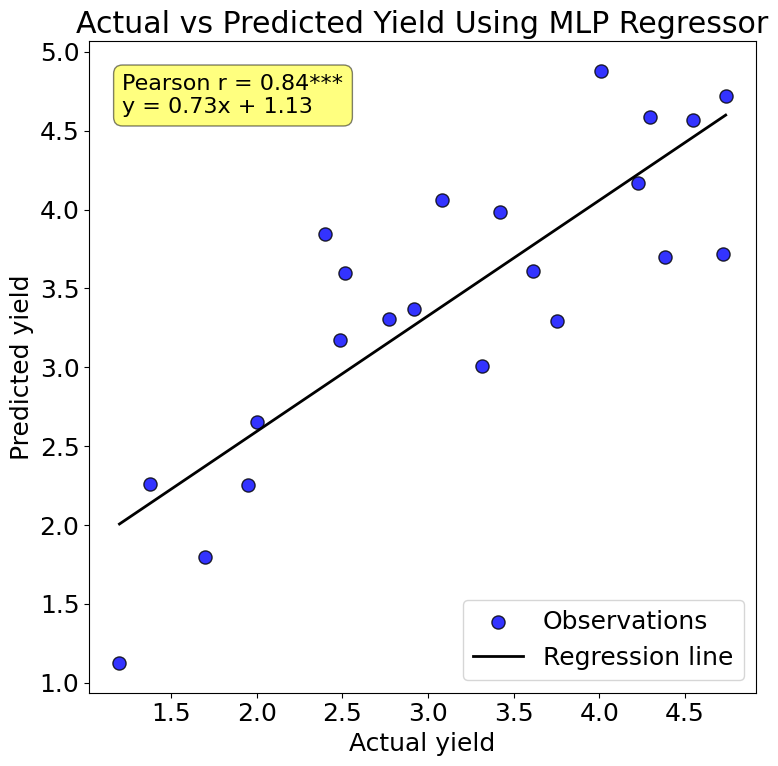

In [16]:
# --------------------------------------------------
# 1. Get corrected predictions from the best MLP model
# --------------------------------------------------

best_x_test_scaled = best_scaler_X.transform(best_x_test)

test_predictions_scaled = best_model.predict(best_x_test_scaled)

test_predictions = best_scaler_y.inverse_transform(
    test_predictions_scaled.reshape(-1, 1)
).ravel()

actual_values = best_y_test.values.ravel()

# --------------------------------------------------
# 2. Calculate statistics
# --------------------------------------------------

correlation, p_value = pearsonr(actual_values, test_predictions)

if p_value < 0.001:
    sig_label = '***'
elif p_value < 0.01:
    sig_label = '**'
elif p_value < 0.05:
    sig_label = '*'
else:
    sig_label = 'ns'

mse = mean_squared_error(actual_values, test_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_values, test_predictions)
r2 = r2_score(actual_values, test_predictions)

slope, intercept, r_value, p_reg, std_err = linregress(
    actual_values, test_predictions
)

x_line = np.linspace(actual_values.min(), actual_values.max(), 200)
y_line = slope * x_line + intercept

# --------------------------------------------------
# 3. Create results dataframe
# --------------------------------------------------

df = pd.DataFrame({
    'Actual_values': actual_values,
    'Predicted_values': test_predictions
})

print(df.head())

# --------------------------------------------------
# 4. Plot Actual vs Predicted
# --------------------------------------------------

plt.rcParams.update({'font.size': 18})

plt.figure(figsize=(8, 8))

plt.scatter(
    actual_values,
    test_predictions,
    color='blue',
    edgecolor='black',
    s=90,
    alpha=0.8,
    label='Observations'
)

# Ideal 1:1 line
# plt.plot(
#     [actual_values.min(), actual_values.max()],
#     [actual_values.min(), actual_values.max()],
#     'r--',
#     linewidth=2,
#     label='1:1 line'
# )

# Regression fit line
plt.plot(
    x_line,
    y_line,
    color='black',
    linewidth=2,
    label='Regression line'
)

plt.xlabel('Actual yield')
plt.ylabel('Predicted yield')
plt.title('Actual vs Predicted Yield Using MLP Regressor')

text_str = (
    f'Pearson r = {correlation:.2f}{sig_label}\n'
    # f'R² = {r2:.2f}\n'
    # f'RMSE = {rmse:.2f}\n'
    # f'MAE = {mae:.2f}\n'
    f'y = {slope:.2f}x + {intercept:.2f}'
)

plt.text(
    0.05,
    0.95,
    text_str,
    transform=plt.gca().transAxes,
    fontsize=16,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='yellow',
        edgecolor='black',
        alpha=0.5
    )
)

plt.legend()
plt.tight_layout()

plt.savefig('MLP_actual_vs_predicted_1.png', dpi=300)
plt.show()